In [1]:
%cd '/Users/lorenzodelcol/Desktop/RA/GFU/REPLICATION DROPBOX (NEW)/Raw data UPDATE/Updated 2026 Series'

/Users/lorenzodelcol/Desktop/RA/GFU/REPLICATION DROPBOX (NEW)/Raw data UPDATE/Updated 2026 Series


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

Did Caggiano and Castelnuovo standardized the unconditional montly standard deviation of the daily returns * 100 of 10Y Bond Yields?


--> Let's check it

In [3]:
df_natural = pd.read_excel('NO_Dummy_Out_PHASE_B_10YR_monthly_df.xlsx')
df_original = pd.read_excel('cc_globalfactor_1992M72020M5.xlsx', sheet_name='raw data')

# Estrazione Data e Belgio dal file "Natural" e formattazione della data
df_nat = df_natural.iloc[:, [0, 5]].copy()
df_nat.columns = ['Date', 'Natural']
df_nat['Date'] = pd.to_datetime(df_nat['Date'])

# Estrazione Data e Belgio dal file "Original" (Colonna S è indice 18) e formattazione della data
df_orig = df_original.iloc[:, [0, 18]].copy()
df_orig.columns = ['Date', 'Original']
df_orig['Date'] = pd.to_datetime(df_orig['Date'])

# Unione dei due dataset usando la data come chiave (inner join)
# Questo garantisce che i mesi siano perfettamente allineati
df_comparison_gfdataset = pd.merge(df_nat, df_orig, on='Date', how='inner')
df_comparison_gfdataset.set_index('Date', inplace=True)

# Standardizzazione SOLO della serie Natural
mean_natural = df_comparison_gfdataset['Natural'].mean()
std_natural = df_comparison_gfdataset['Natural'].std()
df_comparison_gfdataset['Natural_Std'] = (df_comparison_gfdataset['Natural'] - mean_natural) / std_natural

# Visualizzazione dei risultati affiancati
print("Confronto tra serie grezze e Natural standardizzata:")
print(df_comparison_gfdataset[['Natural', 'Original', 'Natural_Std']].head())

Confronto tra serie grezze e Natural standardizzata:
             Natural  Original  Natural_Std
Date                                       
1992-07-01  0.407639  0.094766    -0.182149
1992-08-01  0.362042  0.045748    -0.183563
1992-09-01  0.642437  0.181086    -0.174872
1992-10-01  0.544004  0.146565    -0.177923
1992-11-01  0.425248  0.057063    -0.181604


/opt/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


## The raw series wasn't standardised

## Step 1
### Load the series of the Monthly Standard Deviation of 10 Year Bonds Yield daily returns * 100:
### Natural Vs Dummy Out and we analyse the series with the ELB problems

In [17]:
# File assignments corrected to match their names logically
df_natural = pd.read_excel('NO_Dummy_Out_PHASE_B_10YR_monthly_df.xlsx')
df_dummy_out = pd.read_excel('Dummy_Out_PHASE_B_10YR_monthly_df.xlsx')

# Extract Date (Column A / index 0) and Belgium (Column F / index 5)
dates = df_natural.iloc[:, 0]
belgium_natural = df_natural.iloc[:, 5]
# Fixed the variable name from df_dummy to df_dummy_out
belgium_dummy = df_dummy_out.iloc[:, 5] 

# Create a consolidated DataFrame
df_comparison = pd.DataFrame({
    'Date': dates,
    'Natural': belgium_natural,
    'Dummy_Out': belgium_dummy
})

# Set the Date column as the index for time series plotting
df_comparison['Date'] = pd.to_datetime(df_comparison['Date'])
df_comparison.set_index('Date', inplace=True)

# Drop any NaN values that might have been carried over at the end of the Excel sheet
df_comparison.dropna(inplace=True)

print(df_comparison.head())

             Natural  Dummy_Out
Date                           
1990-01-01  0.666455   0.666455
1990-02-01  0.669249   0.669249
1990-03-01  0.882795   0.882795
1990-04-01  0.343064   0.343064
1990-05-01  0.558073   0.558073


In [18]:
# Calculate statistics for the Natural series
stats_natural = {
    'Mean': df_comparison['Natural'].mean(),
    'Variance': df_comparison['Natural'].var(),
    'SD': df_comparison['Natural'].std(),
    'IQR': df_comparison['Natural'].quantile(0.75) - df_comparison['Natural'].quantile(0.25)
}

# Calculate statistics for the Dummy Out series
stats_dummy = {
    'Mean': df_comparison['Dummy_Out'].mean(),
    'Variance': df_comparison['Dummy_Out'].var(),
    'SD': df_comparison['Dummy_Out'].std(),
    'IQR': df_comparison['Dummy_Out'].quantile(0.75) - df_comparison['Dummy_Out'].quantile(0.25)
}

# Display as a DataFrame
stats_df = pd.DataFrame([stats_natural, stats_dummy], index=['Natural', 'Dummy Out'])
print("\nDescriptive Statistics: Belgium 10YR Bond Volatility")
display(stats_df)


Descriptive Statistics: Belgium 10YR Bond Volatility


,Mean,Variance,SD,IQR
Natural,14.074498,6360.159600,79.750609,1.595431
Dummy Out,1.578488,2.985448,1.727845,1.100635


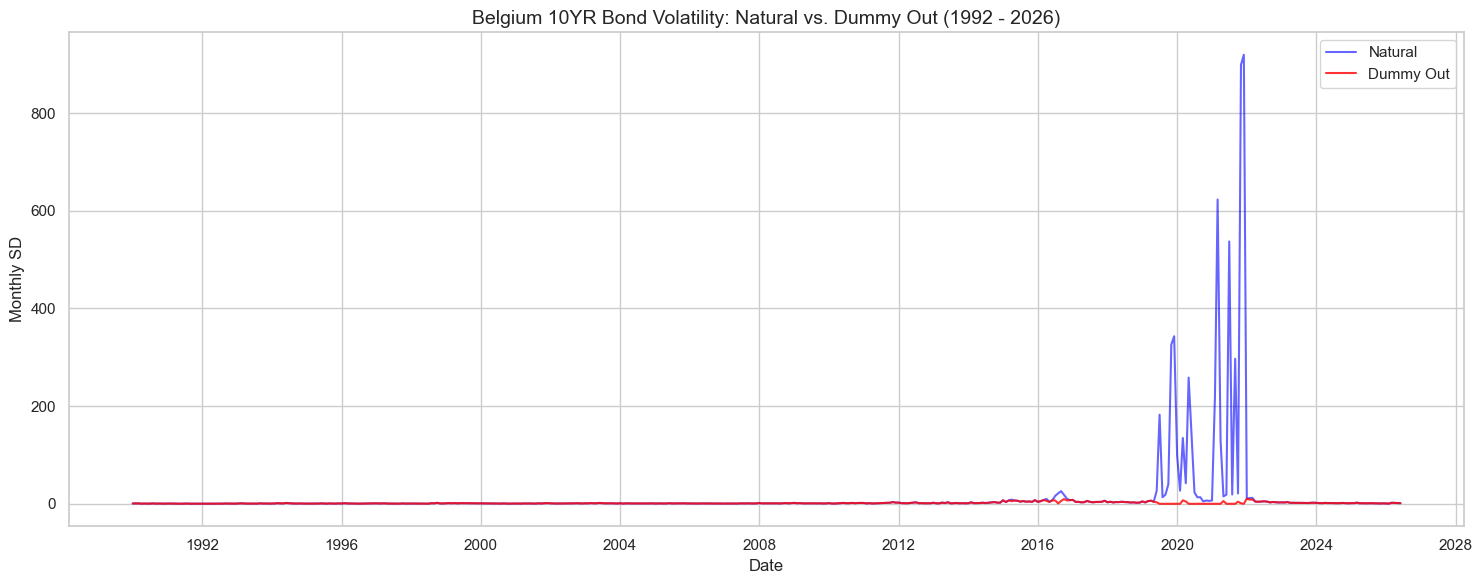

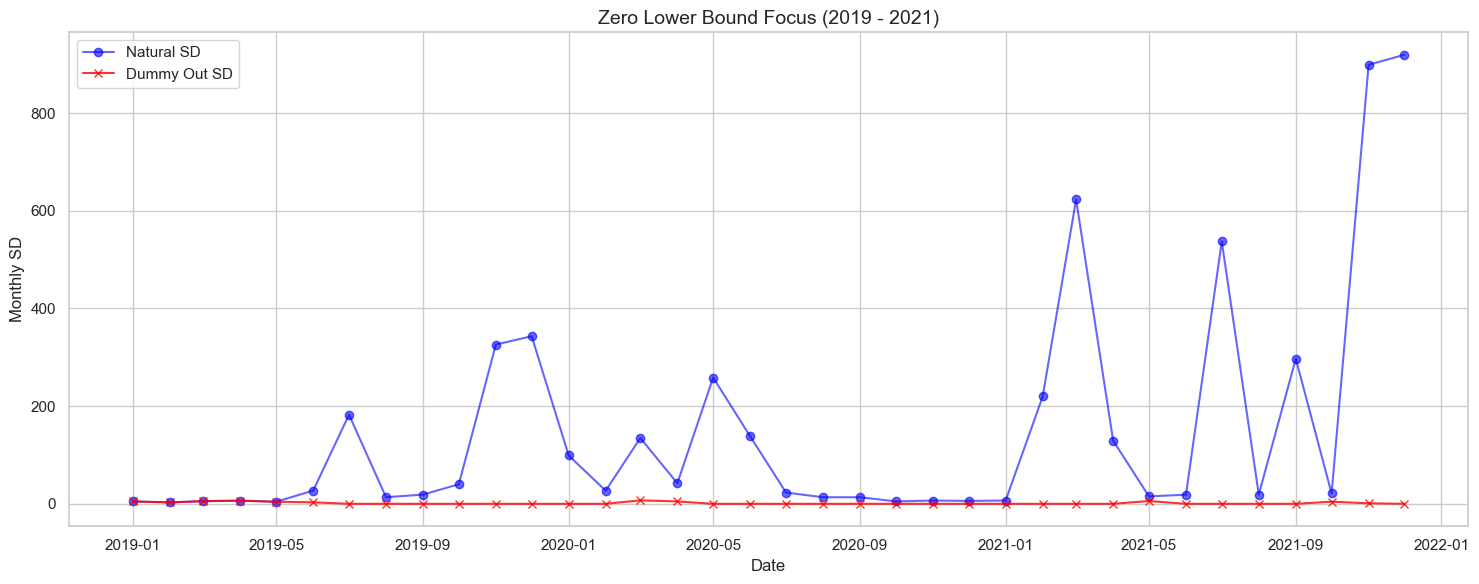

In [21]:
# Set the visual style using Seaborn
sns.set_theme(style="whitegrid")

# PLOT 1: Full Series (1992 - 2026)
plt.figure(figsize=(15, 6))
# df_comparison['Natural'] contains the "NO_Dummy_Out" file (the natural/raw data)
plt.plot(df_comparison.index, df_comparison['Natural'], label='Natural', color='blue', alpha=0.6)
# df_comparison['Dummy_Out'] contains the filtered data
plt.plot(df_comparison.index, df_comparison['Dummy_Out'], label='Dummy Out', color='red', alpha=0.8)

plt.title('Belgium 10YR Bond Volatility: Natural vs. Dummy Out (1992 - 2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Monthly SD', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 2: ELB Focus (2019 - 2021)
# Slice the data to isolate the Zero Lower Bound period
df_elb = df_comparison.loc['2019-01-01':'2021-12-31']

plt.figure(figsize=(15, 6))
# Using markers 'o' and 'x' to see the exact monthly data points during the turbulent period
plt.plot(df_elb.index, df_elb['Natural'], label='Natural SD', color='blue', alpha=0.6, marker='o')
plt.plot(df_elb.index, df_elb['Dummy_Out'], label='Dummy Out SD', color='red', alpha=0.8, marker='x')

plt.title('Zero Lower Bound Focus (2019 - 2021)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Monthly SD', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## Dummy Out Vs Old Dataset

In [23]:
df_natural   = pd.read_excel('NO_Dummy_Out_PHASE_B_10YR_monthly_df.xlsx')
df_dummy_out = pd.read_excel('Dummy_Out_PHASE_B_10YR_monthly_df.xlsx')
df_original  = pd.read_excel('cc_globalfactor_1992M72020M5.xlsx', sheet_name='raw data')



/opt/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)



ANALISI PER: BELGIUM (Periodo Comune: 1992-07 a 2020-05)

1. Statistiche Descrittive:


/opt/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Media,Deviazione Standard (SD),IQR
Serie,,,
Natural,6.2841,32.2620,1.1453
Dummy_Out,1.6064,1.6844,0.8971
Original,0.0789,0.0477,0.0497



2. Matrice di Correlazione di Pearson (Natural vs Dummy vs Original):


,Natural,Dummy_Out,Original
Natural,1.0000,-0.0037,-0.0489
Dummy_Out,-0.0037,1.0000,0.0645
Original,-0.0489,0.0645,1.0000


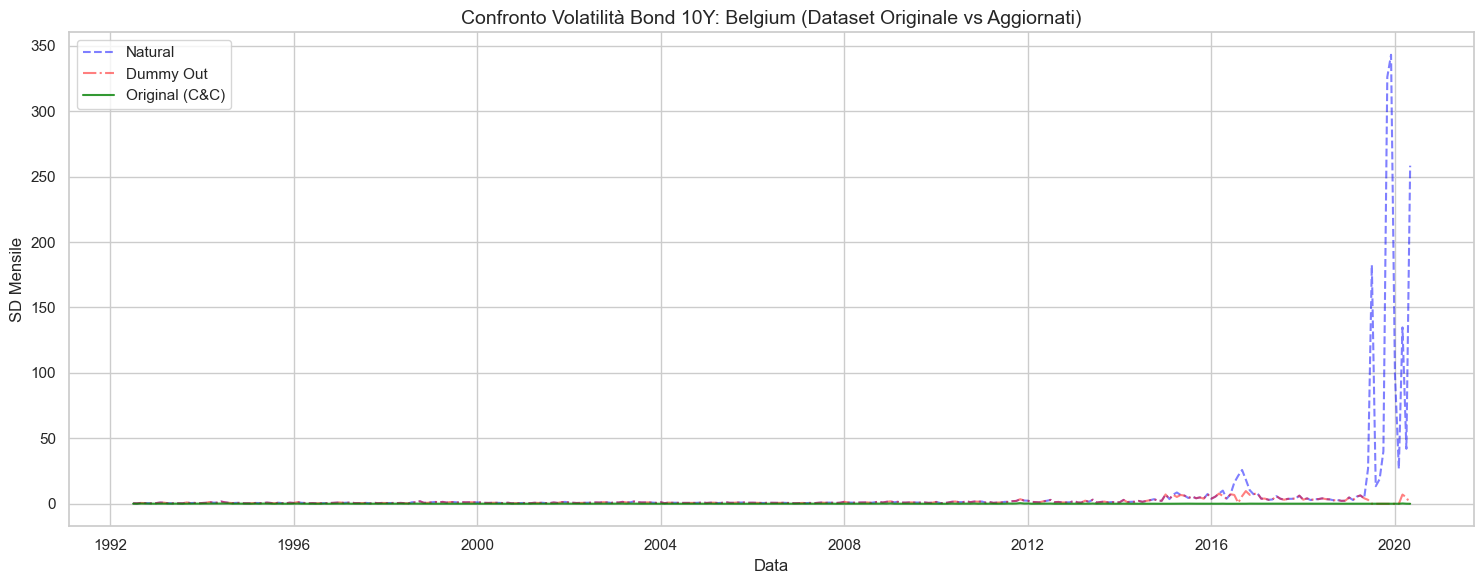


ANALISI PER: FRANCE (Periodo Comune: 1992-07 a 2020-05)

1. Statistiche Descrittive:


,Media,Deviazione Standard (SD),IQR
Serie,,,
Natural,7.9470,42.1679,1.2504
Dummy_Out,1.6794,1.6792,0.9847
Original,0.0783,0.0395,0.0428



2. Matrice di Correlazione di Pearson (Natural vs Dummy vs Original):


,Natural,Dummy_Out,Original
Natural,1.0000,0.0413,0.0231
Dummy_Out,0.0413,1.0000,0.0356
Original,0.0231,0.0356,1.0000


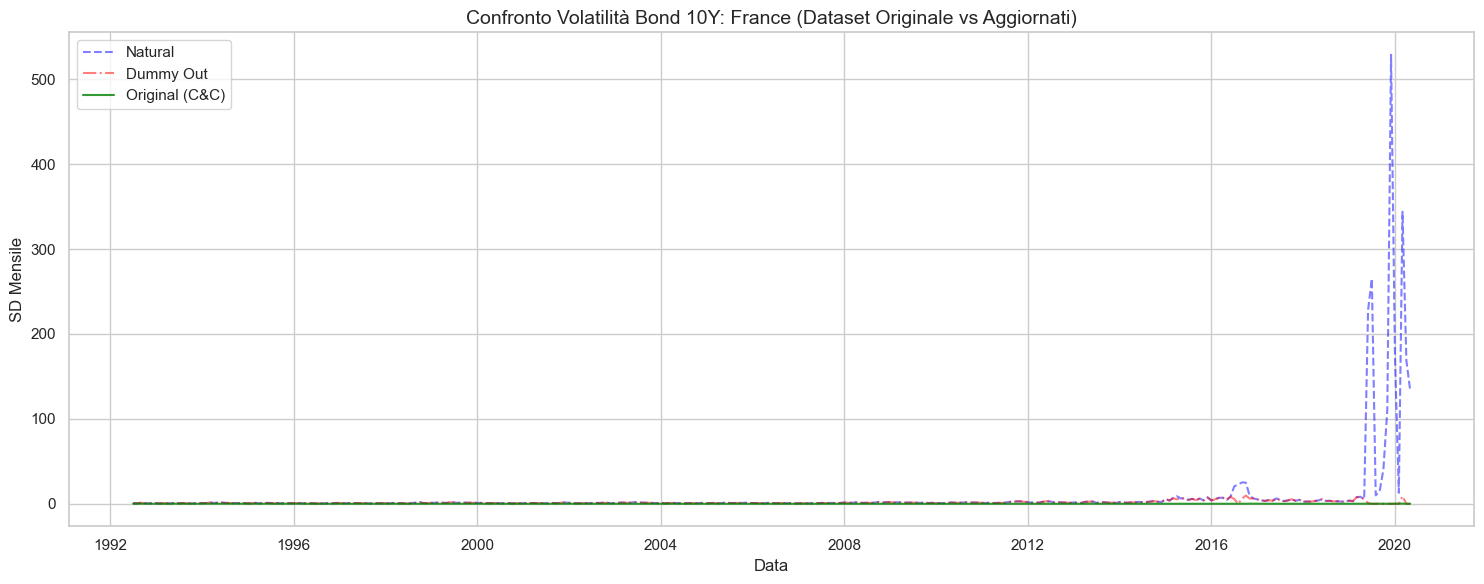


ANALISI PER: GERMANY (Periodo Comune: 1992-07 a 2020-05)

1. Statistiche Descrittive:


,Media,Deviazione Standard (SD),IQR
Serie,,,
Natural,7.4945,35.5691,1.8855
Dummy_Out,1.9147,2.3985,1.3227
Original,0.0747,0.0330,0.0395



2. Matrice di Correlazione di Pearson (Natural vs Dummy vs Original):


,Natural,Dummy_Out,Original
Natural,1.0000,-0.0323,-0.0712
Dummy_Out,-0.0323,1.0000,-0.0543
Original,-0.0712,-0.0543,1.0000


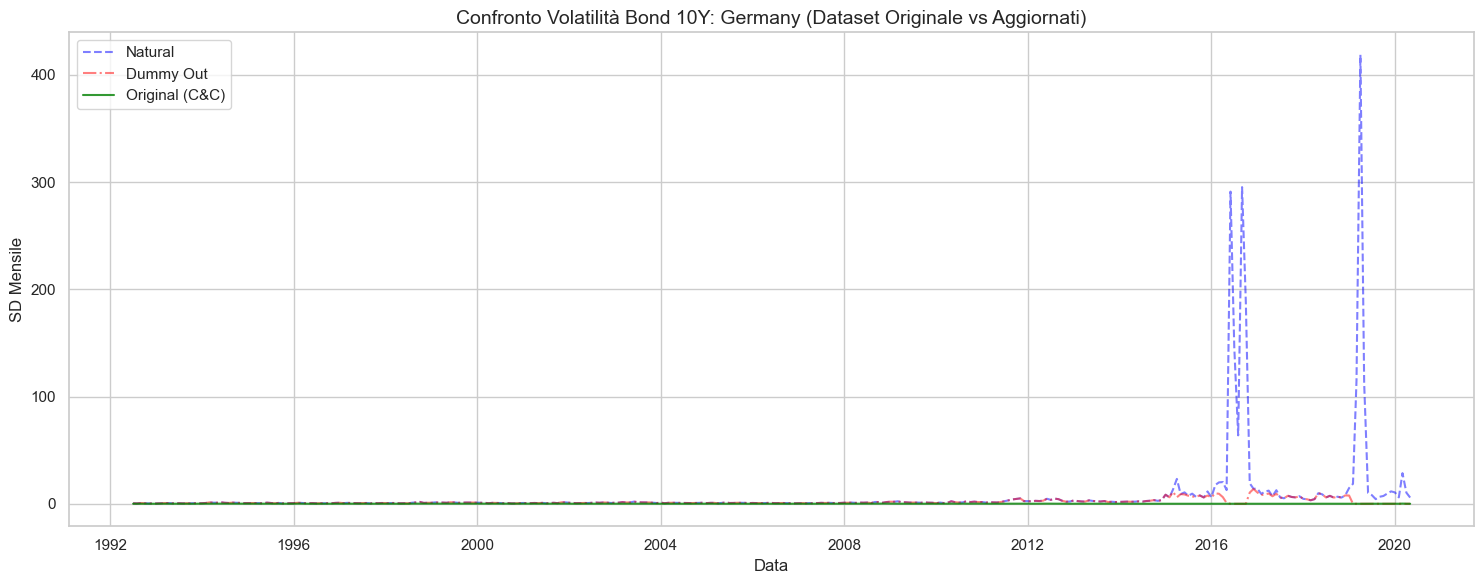

In [24]:
# Caricamento dei tre dataset
df_natural = pd.read_excel('NO_Dummy_Out_PHASE_B_10YR_monthly_df.xlsx')
df_dummy_out = pd.read_excel('Dummy_Out_PHASE_B_10YR_monthly_df.xlsx')
df_original = pd.read_excel('cc_globalfactor_1992M72020M5.xlsx', sheet_name='raw data')

# Preparazione e allineamento degli indici temporali
df_natural['Date'] = pd.to_datetime(df_natural.iloc[:, 0])
df_natural.set_index('Date', inplace=True)

df_dummy_out['Date'] = pd.to_datetime(df_dummy_out.iloc[:, 0])
df_dummy_out.set_index('Date', inplace=True)

df_original['Date'] = pd.to_datetime(df_original.iloc[:, 0])
df_original.set_index('Date', inplace=True)

# Definizione della funzione di analisi per i paesi ELB
def analizza_paese_elb(country_name):
    # Nomi delle colonne nei rispettivi dataset
    col_phase_b = f"SD {country_name}"
    col_original = f"{country_name}_BY"
    
    # Estrazione delle singole serie
    s_nat = df_natural[col_phase_b].rename('Natural')
    s_dum = df_dummy_out[col_phase_b].rename('Dummy_Out')
    s_orig = df_original[col_original].rename('Original')
    
    # Unione (inner join per isolare automaticamente il periodo comune 1992-2020)
    df_merged = pd.concat([s_nat, s_dum, s_orig], axis=1, join='inner').dropna()
    
    # --- STATISTICHE DESCRITTIVE ---
    stats = []
    for col in df_merged.columns:
        stats.append({
            'Serie': col,
            'Media': df_merged[col].mean(),
            'Deviazione Standard (SD)': df_merged[col].std(),
            'IQR': df_merged[col].quantile(0.75) - df_merged[col].quantile(0.25)
        })
    
    df_stats = pd.DataFrame(stats).set_index('Serie')
    
    # --- CORRELAZIONE ---
    df_corr = df_merged.corr()
    
    # Stampa dei risultati nella console
    print(f"\n{'='*60}")
    print(f"ANALISI PER: {country_name.upper()} (Periodo Comune: {df_merged.index.min().strftime('%Y-%m')} a {df_merged.index.max().strftime('%Y-%m')})")
    print(f"{'='*60}")
    
    print("\n1. Statistiche Descrittive:")
    display(df_stats.round(4))
    
    print("\n2. Matrice di Correlazione di Pearson (Natural vs Dummy vs Original):")
    display(df_corr.round(4))
    
    # --- VISUALIZZAZIONE ---
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(15, 6))
    
    plt.plot(df_merged.index, df_merged['Natural'], label='Natural', color='blue', alpha=0.5, linestyle='--')
    plt.plot(df_merged.index, df_merged['Dummy_Out'], label='Dummy Out', color='red', alpha=0.5, linestyle='-.')
    plt.plot(df_merged.index, df_merged['Original'], label='Original (C&C)', color='green', alpha=0.8)
    
    plt.title(f'Confronto Volatilità Bond 10Y: {country_name} (Dataset Originale vs Aggiornati)', fontsize=14)
    plt.xlabel('Data', fontsize=12)
    plt.ylabel('SD Mensile', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Esecuzione dell'analisi per i principali paesi che hanno toccato lo Zero Lower Bound (ELB)
paesi_elb = ['Belgium', 'France', 'Germany']

for paese in paesi_elb:
    try:
        analizza_paese_elb(paese)
    except KeyError as e:
        print(f"Attenzione: Dati non trovati per {paese}. Verifica i nomi delle colonne. Errore: {e}")